In [1]:
XENIUM_DATA_DIR = '/global/scratch/users/fosterangus/MetabTravLR/Data/Xenium'
DATASET_NAME = 'Human_Cervical_Cancer'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 840387 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'Cytotoxic_CD8_score', 'Exhausted_CD8_score', 'Treg_score', 'cd8', 'cd4', 't_cell', 'sub_cluster_5_res_1', 'sub_cluster_5_res_0.75', 'sub_cluster_5_res_0.5', 'sub_cluster_5_res_0.37', 'sub_cluster_5_res_0.25', 'sub_cluster_5_res_0.15', 'sub_cluster_5_res_0.1', 'sub_cluster_5_res_0.05', 'sub_cluster_1-4_res_1', 'sub_cluster_1-4_res_0.75', 'sub_cluster_1-4_res_0.5', 'sub_cluster_1-4

/tmp/ipykernel_225368/12019399.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');


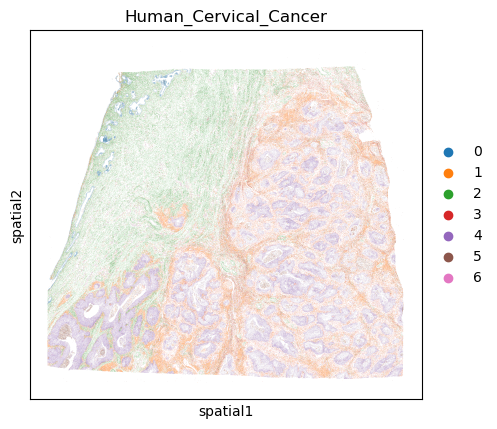

In [4]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');

In [5]:
# Make sure counts layer exists
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

# Build log_norm layer from counts if it doesn't exist
if 'log_norm' not in adata.layers:
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers['log_norm'] = adata.X.copy()
    # Restore raw counts to X
    adata.X = adata.layers['counts'].copy()

print("Layers available:", list(adata.layers.keys()))
print("X max (should be large if raw counts):", adata.X.max())
print("log_norm max (should be small, ~log scale):", adata.layers['log_norm'].max())

Layers available: ['counts', 'log_norm']
X max (should be large if raw counts): 387.0
log_norm max (should be small, ~log scale): 9.210441


In [6]:
# resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5, 0.375, 0.25, 0.1, 0.05]
resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5]
def res_label(res):
    return f'leiden_scVI_res_{res}'
res_labels = [res_label(res) for res in resolutions]

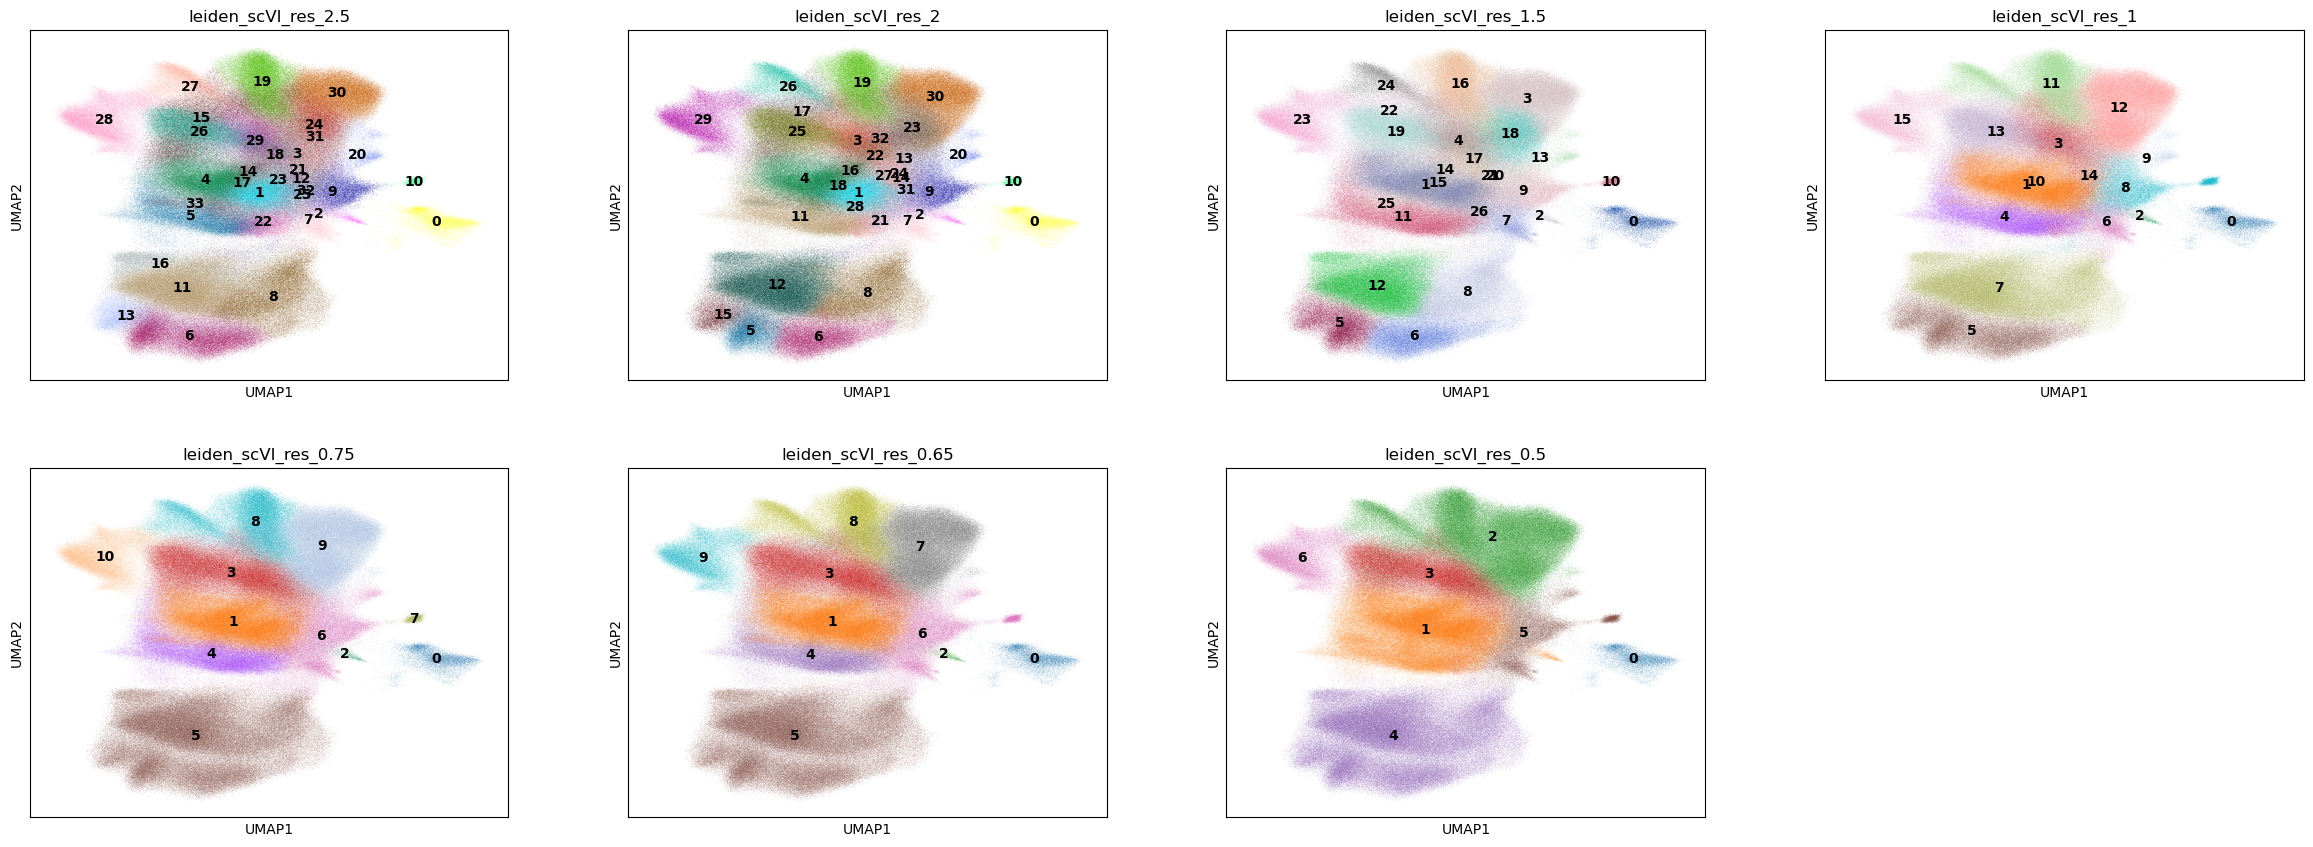

In [7]:
sc.pl.umap(adata, color=res_labels, legend_loc="on data")


RESOLUTION: leiden_scVI_res_2.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['MUC5B', 'AGR2', 'XBP1', 'BPIFB1', 'KIAA1324', 'SLC40A1', 'THSD4', 'SORD', 'PTGS2', 'PKM', 'ESR1', 'HIF1A', 'PAM', 'GREB1', 'MUC5AC']
Cluster 1: ['IL7R', 'TRAC', 'CD8A', 'TRBC1', 'CXCR4', 'CD52', 'MIAT', 'CD3E', 'CTLA4', 'CD3D', 'CD2', 'SH2D1A', 'IKZF1', 'BIRC3', 'GIMAP4']
Cluster 2: ['ADCYAP1', 'KIT', 'SLC2A3', 'MS4A2', 'SLC18A2', 'IL1RL1', 'CTSG', 'GATA2', 'HDC', 'IL18R1', 'ACSL4', 'BIRC3', 'SIGLEC6', 'PTGS2', 'HPGD']
Cluster 3: ['LUM', 'THBS1', 'GREM1', 'CCN1', 'CCN2', 'TIMP2', 'THY1', 'ABI3BP', 'COL5A2', 'CTSK', 'CCL2', 'MYL9', 'DIO2', 'PDPN', 'PDGFRA']
Cluster 4: ['EEF1G', 'IL7R', 'TRAC', 'CD52', 'TRBC1', 'CXCR4', 'CD8A', 'MIAT', 'CD3E', 'CD3D', 'CDKN1B', 'BIRC3', 'IKZF1', 'CTLA4', 'CD2']
Cluster 5: ['C1QC', 'AIF1', 'MS4A6A', 'FCGR2A', 'MRC1', 'ITGB2', 'C5AR1', 'NAMPT', 'SLC2A3', 'STAB1', 'CD14', 'MNDA', 'THBS1', 'CIITA', 'LIPA']
Cluster 6: ['DSC3', 'HSPB1', 'TRIM29', 'H3F3B', 'RAC1', 'SPRR3', 'MALL', 'DSG3', 'EMP2', 'HNRNPD

/tmp/ipykernel_225368/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225368/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2.5                                                         
0                              -0.047138            -0.050587   -0.057367   
1                               0.199650             0.198199    0.181081   
2                              -0.010283            -0.004580   -0.001242   
3                              -0.005784            -0.003464   -0.002425   
4                               0.226720             0.227988    0.227599   
5                              -0.018229             0.019334    0.081986   
6                              -0.078701            -0.071394   -0.078770   
7                               0.000843             0.003399    0.005260   
8                              -0.044752            -0.044712   -0.045910   
9                              -0.003229            -0.003020   -0.004029   
10        

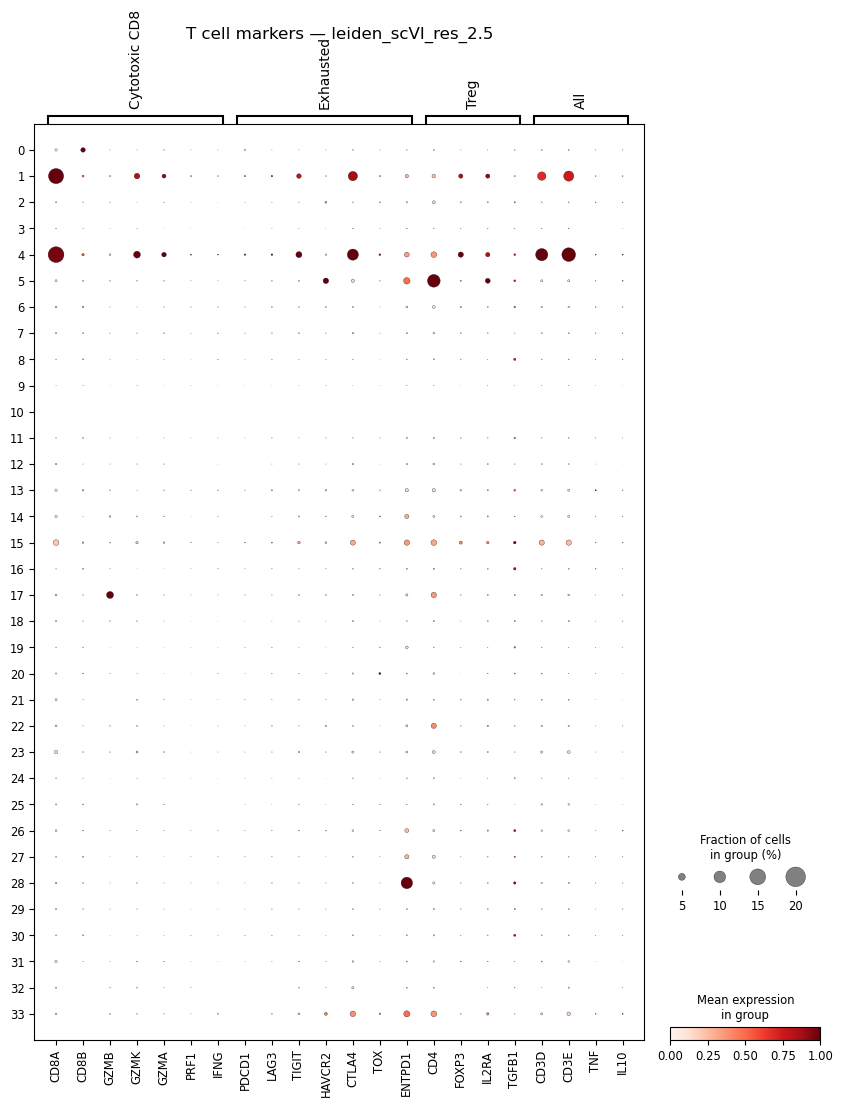


RESOLUTION: leiden_scVI_res_2


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['MUC5B', 'AGR2', 'XBP1', 'BPIFB1', 'KIAA1324', 'SLC40A1', 'THSD4', 'SORD', 'PTGS2', 'PKM', 'ESR1', 'HIF1A', 'PAM', 'GREB1', 'MUC5AC']
Cluster 1: ['IL7R', 'TRAC', 'CD8A', 'TRBC1', 'CD52', 'CXCR4', 'MIAT', 'CD3E', 'CTLA4', 'CD3D', 'CD2', 'SH2D1A', 'IKZF1', 'BIRC3', 'GZMK']
Cluster 2: ['ADCYAP1', 'KIT', 'SLC2A3', 'MS4A2', 'SLC18A2', 'IL1RL1', 'CTSG', 'GATA2', 'HDC', 'IL18R1', 'ACSL4', 'BIRC3', 'SIGLEC6', 'PTGS2', 'HPGD']
Cluster 3: ['NAMPT', 'CCDC71L', 'THBS1', 'GREM1', 'SFRP4', 'BGN', 'LUM', 'ADAMTS4', 'LTBP2', 'C11orf96', 'SOCS3', 'CCN4', 'TIMP2', 'CCL2', 'PDPN']
Cluster 4: ['EEF1G', 'IL7R', 'TRAC', 'CD52', 'TRBC1', 'CXCR4', 'CD8A', 'MIAT', 'CD3E', 'CD3D', 'CDKN1B', 'BIRC3', 'IKZF1', 'CTLA4', 'CD2']
Cluster 5: ['HSPB1', 'DSC3', 'H3F3B', 'TNS4', 'AHCY', 'HNRNPD', 'TRIM29', 'TUBB', 'CLDN1', 'SMC4', 'DST', 'NFE2L2', 'SOD1', 'SRSF1', 'RAC1']
Cluster 6: ['SPRR3', 'DSC3', 'MALL', 'DSG3', 'HSPB1', 'TRIM29', 'RAC1', 'H3F3B', 'YWHAZ', 'CDK

/tmp/ipykernel_225368/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225368/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2                                                         
0                            -0.047637            -0.051156   -0.057777   
1                             0.187679             0.187562    0.172708   
2                            -0.010727            -0.006022   -0.001939   
3                            -0.008973            -0.005908   -0.005071   
4                             0.241317             0.241639    0.239579   
5                            -0.070409            -0.060876   -0.067259   
6                            -0.082178            -0.077128   -0.083778   
7                            -0.000156             0.001818    0.003417   
8                            -0.042652            -0.042651   -0.043230   
9                            -0.003296            -0.003006   -0.004040   
10                           -0.00

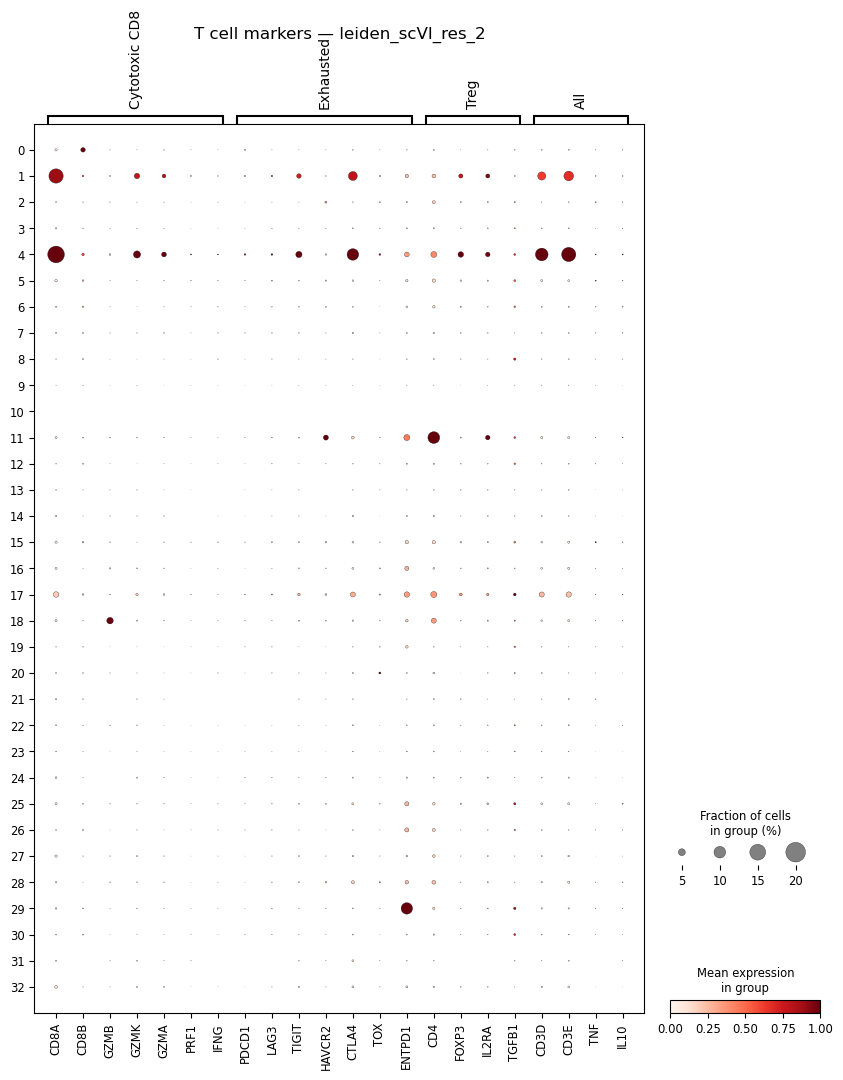


RESOLUTION: leiden_scVI_res_1.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['MUC5B', 'AGR2', 'XBP1', 'BPIFB1', 'KIAA1324', 'SLC40A1', 'THSD4', 'SORD', 'PTGS2', 'PKM', 'ESR1', 'HIF1A', 'PAM', 'GREB1', 'MUC5AC']
Cluster 1: ['IL7R', 'TRAC', 'CD52', 'TRBC1', 'CD8A', 'CXCR4', 'MIAT', 'CD3E', 'EEF1G', 'CD3D', 'CTLA4', 'IKZF1', 'BIRC3', 'CD2', 'CDKN1B']
Cluster 2: ['ADCYAP1', 'KIT', 'MS4A2', 'SLC18A2', 'IL1RL1', 'CTSG', 'GATA2', 'HDC', 'IL18R1', 'ACSL4', 'BIRC3', 'SLC2A3', 'SIGLEC6', 'PTGS2', 'HPGD']
Cluster 3: ['SFRP4', 'PLPP3', 'DCN', 'COL5A1', 'SFRP1', 'TIMP3', 'MEG3', 'LUM', 'H19', 'SNAI2', 'NBL1', 'GREB1', 'CCDC80', 'ESR1', 'LTBP1']
Cluster 4: ['NAMPT', 'CCDC71L', 'THBS1', 'SFRP4', 'GREM1', 'BGN', 'LUM', 'ADAMTS4', 'LTBP2', 'C11orf96', 'TIMP2', 'SOCS3', 'CCL2', 'CCN4', 'CTSK']
Cluster 5: ['DSC3', 'HSPB1', 'H3F3B', 'AHCY', 'PKM', 'TUBB', 'TRIM29', 'TNS4', 'PLP2', 'LDHA', 'SOD1', 'SMC4', 'HNRNPD', 'EMP2', 'EIF3C']
Cluster 6: ['SPRR3', 'DSC3', 'MALL', 'HSPB1', 'DSG3', 'TRIM29', 'RAC1', 'H3F3B', 'YWHAZ', 'CDKN

/tmp/ipykernel_225368/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225368/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1.5                                                         
0                              -0.047503            -0.051057   -0.057862   
1                               0.225999             0.225454    0.216840   
2                              -0.017959            -0.011493   -0.007087   
3                              -0.026906            -0.024809   -0.019859   
4                              -0.007315            -0.004630   -0.004071   
5                              -0.068408            -0.059563   -0.067031   
6                              -0.083128            -0.077703   -0.084567   
7                               0.000183             0.002108    0.003472   
8                              -0.041491            -0.041556   -0.041796   
9                              -0.002583            -0.000477   -0.000448   
10        

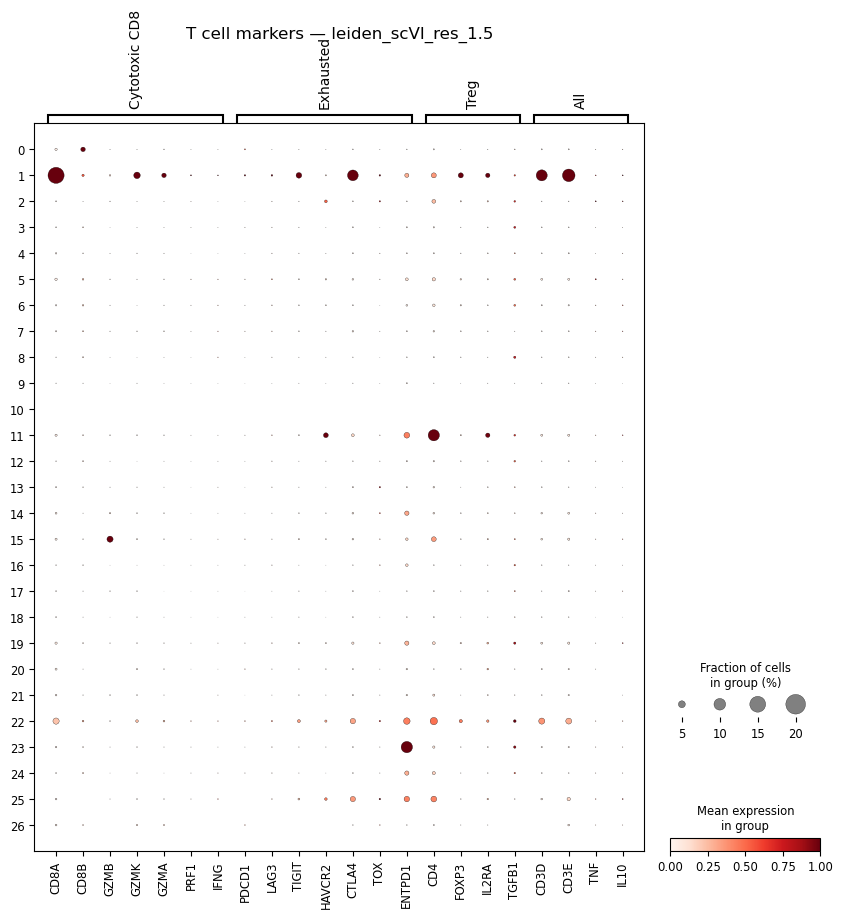


RESOLUTION: leiden_scVI_res_1

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['MUC5B', 'AGR2', 'XBP1', 'BPIFB1', 'KIAA1324', 'SLC40A1', 'THSD4', 'SORD', 'PTGS2', 'PKM', 'ESR1', 'HIF1A', 'PAM', 'GREB1', 'MUC5AC']
Cluster 1: ['IL7R', 'TRAC', 'CD52', 'TRBC1', 'CXCR4', 'CD8A', 'MIAT', 'CD3E', 'EEF1G', 'CD3D', 'CTLA4', 'IKZF1', 'BIRC3', 'CDKN1B', 'CD2']
Cluster 2: ['ADCYAP1', 'KIT', 'SLC18A2', 'MS4A2', 'IL1RL1', 'CTSG', 'GATA2', 'HDC', 'IL18R1', 'ACSL4', 'BIRC3', 'SIGLEC6', 'SLC2A3', 'HPGD', 'PTGS2']
Cluster 3: ['NAMPT', 'CCDC71L', 'THBS1', 'GREM1', 'BGN', 'SFRP4', 'LUM', 'ADAMTS4', 'NOTCH2NLA', 'C11orf96', 'LTBP2', 'CCN4', 'SOCS3', 'CCL2', 'PDPN']
Cluster 4: ['C1QC', 'AIF1', 'MS4A6A', 'FCGR2A', 'MRC1', 'ITGB2', 'C5AR1', 'SLC2A3', 'STAB1', 'CD14', 'MNDA', 'CIITA', 'NAMPT', 'CD4', 'CYBB']
Cluster 5: ['DSC3', 'HSPB1', 'TRIM29', 'H3F3B', 'RAC1', 'SPRR3', 'EMP2', 'DSG3', 'YWHAZ', 'ANXA2', 'LDHA', 'PLP2', 'MALL', 'TNS4', 'HNRNPD']
Cluster 6: ['SOX2-OT', 'SOST', 'DUX4', 'CDC27', 'ALG11'

/tmp/ipykernel_225368/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225368/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1                                                         
0                            -0.048231            -0.051545   -0.058029   
1                             0.210719             0.211067    0.203309   
2                            -0.018140            -0.012633   -0.008636   
3                            -0.008893            -0.006257   -0.005486   
4                            -0.013166             0.017563    0.069001   
5                            -0.076425            -0.069297   -0.076466   
6                            -0.001555             0.000289    0.001538   
7                            -0.048860            -0.047113   -0.048928   
8                            -0.003377            -0.002747   -0.003461   
9                            -0.019747            -0.015393   -0.020805   
10                            0.01

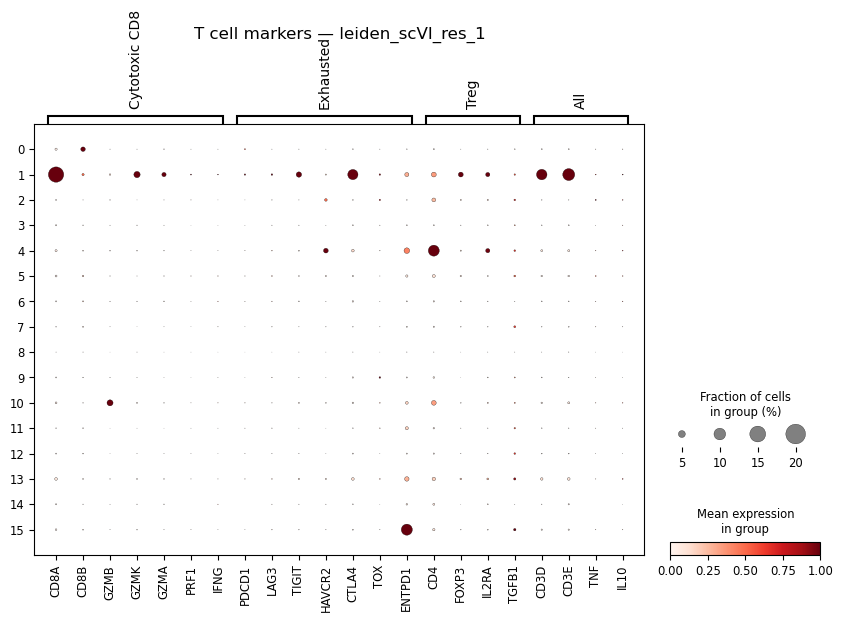


RESOLUTION: leiden_scVI_res_0.75

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['MUC5B', 'AGR2', 'XBP1', 'BPIFB1', 'KIAA1324', 'SLC40A1', 'THSD4', 'SORD', 'PTGS2', 'PKM', 'ESR1', 'HIF1A', 'PAM', 'GREB1', 'MUC5AC']
Cluster 1: ['IL7R', 'TRAC', 'EEF1G', 'CD52', 'CXCR4', 'TRBC1', 'CD8A', 'MIAT', 'CD3E', 'IKZF1', 'BIRC3', 'CD3D', 'CTLA4', 'CD2', 'CDKN1B']
Cluster 2: ['ADCYAP1', 'KIT', 'MS4A2', 'SLC18A2', 'IL1RL1', 'CTSG', 'GATA2', 'HDC', 'ACSL4', 'BIRC3', 'IL18R1', 'SIGLEC6', 'PTGS2', 'SLC2A3', 'HPGD']
Cluster 3: ['BGN', 'LUM', 'CCDC71L', 'COL5A1', 'TIMP2', 'THBS1', 'SULF1', 'POSTN', 'THY1', 'COL5A2', 'GREM1', 'MMP14', 'NAMPT', 'SFRP4', 'MYL9']
Cluster 4: ['C1QC', 'AIF1', 'MS4A6A', 'FCGR2A', 'MRC1', 'ITGB2', 'NAMPT', 'C5AR1', 'SLC2A3', 'MNDA', 'STAB1', 'CD14', 'CIITA', 'CD4', 'CYBB']
Cluster 5: ['DSC3', 'HSPB1', 'TRIM29', 'DSG3', 'ANXA2', 'SPRR3', 'LDHA', 'CDKN1A', 'H3F3B', 'RAC1', 'NDRG1', 'PKM', 'YWHAZ', 'PLP2', 'MALL']
Cluster 6: ['SOX2-OT', 'AQP7', 'DUX4', 'SOX10', 'L1CAM', '

/tmp/ipykernel_225368/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225368/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.75                                                         
0                               -0.047919            -0.051366   -0.058081   
1                                0.161945             0.163189    0.157530   
2                               -0.019813            -0.013269   -0.008619   
3                               -0.013326            -0.004169    0.005945   
4                               -0.013412             0.016128    0.065986   
5                               -0.057940            -0.054407   -0.058006   
6                               -0.004799            -0.003520   -0.004644   
7                               -0.000091            -0.000113   -0.000130   
8                               -0.027477            -0.020301   -0.016928   
9                               -0.021343            -0.019117   -0.015016  

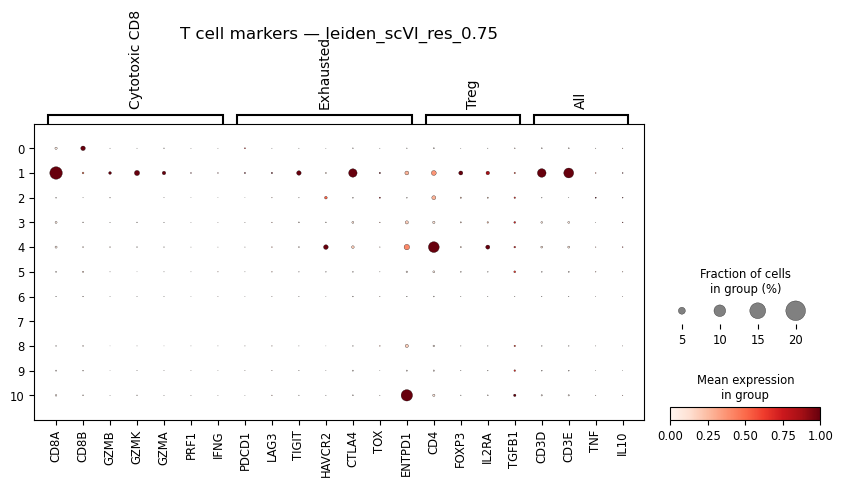


RESOLUTION: leiden_scVI_res_0.65

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['MUC5B', 'AGR2', 'XBP1', 'BPIFB1', 'KIAA1324', 'SLC40A1', 'THSD4', 'SORD', 'PTGS2', 'PKM', 'ESR1', 'HIF1A', 'PAM', 'GREB1', 'MUC5AC']
Cluster 1: ['IL7R', 'EEF1G', 'TRAC', 'CD52', 'CXCR4', 'TRBC1', 'CD8A', 'MIAT', 'CD3E', 'IKZF1', 'BIRC3', 'CD3D', 'CTLA4', 'CD2', 'CDKN1B']
Cluster 2: ['ADCYAP1', 'KIT', 'MS4A2', 'SLC18A2', 'IL1RL1', 'CTSG', 'GATA2', 'HDC', 'IL18R1', 'ACSL4', 'BIRC3', 'SIGLEC6', 'PTGS2', 'SLC2A3', 'HPGD']
Cluster 3: ['BGN', 'LUM', 'CCDC71L', 'COL5A1', 'TIMP2', 'SULF1', 'THBS1', 'POSTN', 'THY1', 'COL5A2', 'GREM1', 'MMP14', 'NAMPT', 'SFRP4', 'MYL9']
Cluster 4: ['C1QC', 'AIF1', 'MS4A6A', 'FCGR2A', 'MRC1', 'ITGB2', 'NAMPT', 'C5AR1', 'SLC2A3', 'MNDA', 'STAB1', 'CD14', 'CYBB', 'CIITA', 'CD4']
Cluster 5: ['DSC3', 'HSPB1', 'TRIM29', 'DSG3', 'ANXA2', 'SPRR3', 'LDHA', 'CDKN1A', 'H3F3B', 'RAC1', 'NDRG1', 'PKM', 'YWHAZ', 'PLP2', 'MALL']
Cluster 6: ['SOX2-OT', 'AQP7', 'DUX4', 'SOX10', 'L1CAM', '

/tmp/ipykernel_225368/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225368/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.65                                                         
0                               -0.048411            -0.051723   -0.058243   
1                                0.159361             0.160970    0.155767   
2                               -0.019745            -0.013410   -0.009107   
3                               -0.013481            -0.004194    0.006145   
4                               -0.014148             0.014897    0.064504   
5                               -0.057810            -0.054246   -0.057804   
6                               -0.004497            -0.003472   -0.004447   
7                               -0.021192            -0.018875   -0.014659   
8                               -0.027556            -0.020311   -0.017032   
9                               -0.047332            -0.010213    0.003467  

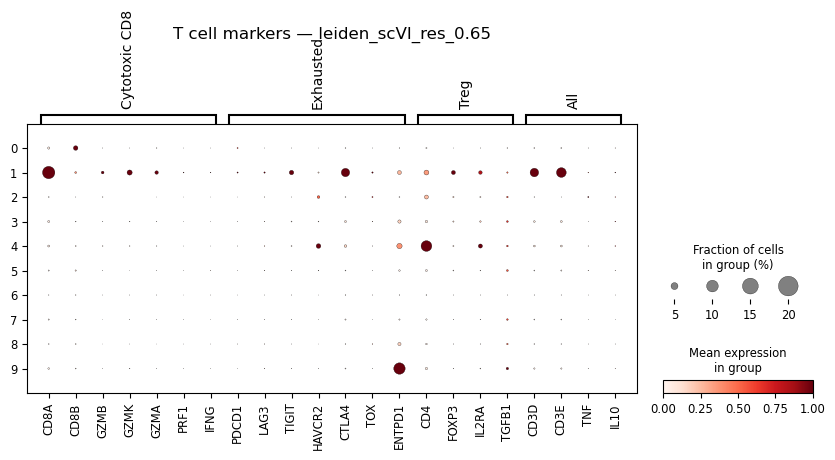


RESOLUTION: leiden_scVI_res_0.5

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['MUC5B', 'AGR2', 'XBP1', 'BPIFB1', 'KIAA1324', 'SLC40A1', 'THSD4', 'SORD', 'PTGS2', 'PKM', 'ESR1', 'HIF1A', 'PAM', 'GREB1', 'MUC5AC']
Cluster 1: ['IL7R', 'TRAC', 'EEF1G', 'CD52', 'AIF1', 'CXCR4', 'C1QC', 'TRBC1', 'MS4A6A', 'CD8A', 'ITGB2', 'FCGR2A', 'MIAT', 'MRC1', 'CD3E']
Cluster 2: ['PLPP3', 'SFRP4', 'MYH11', 'TIMP3', 'MYL9', 'COL5A1', 'SFRP1', 'DCN', 'ADAMTS1', 'CCDC80', 'BGN', 'MEG3', 'LTBP2', 'NBL1', 'C11orf96']
Cluster 3: ['BGN', 'LUM', 'CCDC71L', 'COL5A1', 'TIMP2', 'SULF1', 'THBS1', 'POSTN', 'THY1', 'COL5A2', 'NAMPT', 'GREM1', 'MMP14', 'SFRP4', 'MYL9']
Cluster 4: ['DSC3', 'HSPB1', 'TRIM29', 'SPRR3', 'DSG3', 'ANXA2', 'LDHA', 'CDKN1A', 'H3F3B', 'RAC1', 'NDRG1', 'PKM', 'YWHAZ', 'PLP2', 'MALL']
Cluster 5: ['SOX2-OT', 'AQP7', 'DUX4', 'SOX10', 'L1CAM', 'SCN7A', 'PCDH20', 'MPZ', 'CCN3', 'ABCA8', 'CADM3', 'MYOT', 'ADRB1', 'SORCS1', 'GAP43']
Cluster 6: ['AQP1', 'SLCO2A1', 'FLT1', 'EPAS1', 'APP', 'PL

/tmp/ipykernel_225368/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225368/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.5                                                         
0                              -0.048269            -0.051589   -0.058199   
1                               0.102385             0.112764    0.125094   
2                              -0.023267            -0.018956   -0.014987   
3                              -0.014576            -0.005709    0.004490   
4                              -0.057457            -0.053699   -0.057059   
5                              -0.004664            -0.003806   -0.005180   
6                              -0.047528            -0.010380    0.003143   

                     cell_count  
leiden_scVI_res_0.5              
0                         12508  
1                        206201  
2                        205665  
3                        109287  
4                        225603  
5 

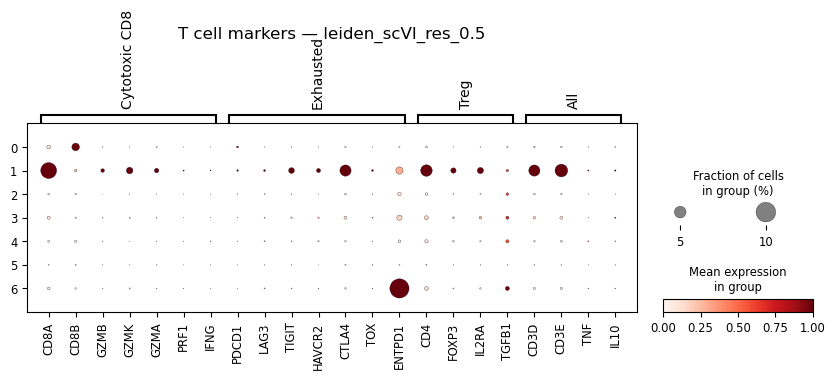

In [8]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

marker_genes_dotplot = {
    'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
    'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    'All': ['CD3D', 'CD3E', 'TNF', 'IL10'],
}


def annotate_clusters(adata, groupby_key, n_top_genes=15, de_genes_dict=None):
    print(f"\n{'='*60}")
    print(f"RESOLUTION: {groupby_key}")
    print(f"{'='*60}")
    
    # --- Approach 1: top DE genes per cluster (on log_norm) ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby_key,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    
    # Initialize dictionary for this resolution if provided
    if de_genes_dict is not None:
        de_genes_dict[groupby_key] = {}
    
    print("\n--- Top DE genes per cluster (log_norm) ---")
    for group in groups:
        top_genes = result['names'][group][:n_top_genes]
        print(f"Cluster {group}: {list(top_genes)}")
        # Save DE genes to the dictionary
        if de_genes_dict is not None:
            de_genes_dict[groupby_key][group] = list(top_genes)
    
    # --- Approach 2: marker set scores per cluster (on log_norm) ---
    for name, genes in marker_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f'{name}_score',
            layer='log_norm'
        )
    
    score_cols = [f'{name}_score' for name in marker_sets.keys()]

    # 1. Calculate the mean scores per cluster
    cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
    # 2. Calculate the cell count per cluster and add it as a new column
    cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()
    print("\n--- Marker set scores and cell counts per cluster (log_norm) ---")
    print(cluster_scores)
    
    # --- Approach 3: dot plot (on log_norm) ---
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )
    
    return cluster_scores

# Initialize the dictionary and run the loop
de_genes_dict = {}
all_scores = {}
for res_key in res_labels:
    all_scores[res_key] = annotate_clusters(adata, res_key, de_genes_dict=de_genes_dict)

In [9]:
all_scores[res_label(2.5)]

,Cytotoxic_CD8_score,Exhausted_CD8_score,Treg_score,cell_count
leiden_scVI_res_2.5,,,,
0,-0.047138,-0.050587,-0.057367,12657
1,0.199650,0.198199,0.181081,39922
2,-0.010283,-0.004580,-0.001242,3594
3,-0.005784,-0.003464,-0.002425,9117
4,0.226720,0.227988,0.227599,51754
5,-0.018229,0.019334,0.081986,48377
6,-0.078701,-0.071394,-0.078770,53651
7,0.000843,0.003399,0.005260,21685
8,-0.044752,-0.044712,-0.045910,54083


/tmp/ipykernel_225368/1778114892.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');


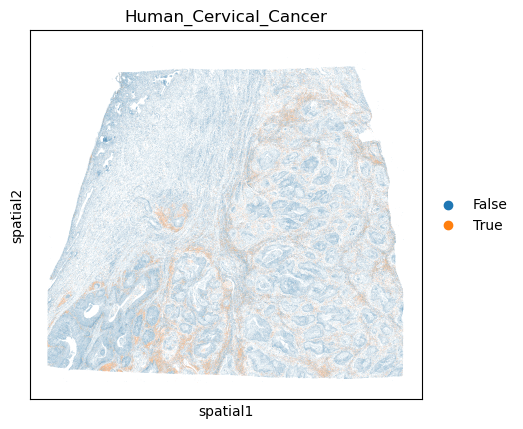

In [10]:
res = 2.5
cd8 = ['1', '4'] #CD8
cd4 = ['5'] #CD4
t_cell_clusts = list(set(cd8 + cd4))
adata.obs['cd8'] = adata.obs[res_label(res)].isin(cd8) 
adata.obs['cd4'] = adata.obs[res_label(res)].isin(cd4)
adata.obs['t_cell'] = adata.obs[res_label(res)].isin(t_cell_clusts) 
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');

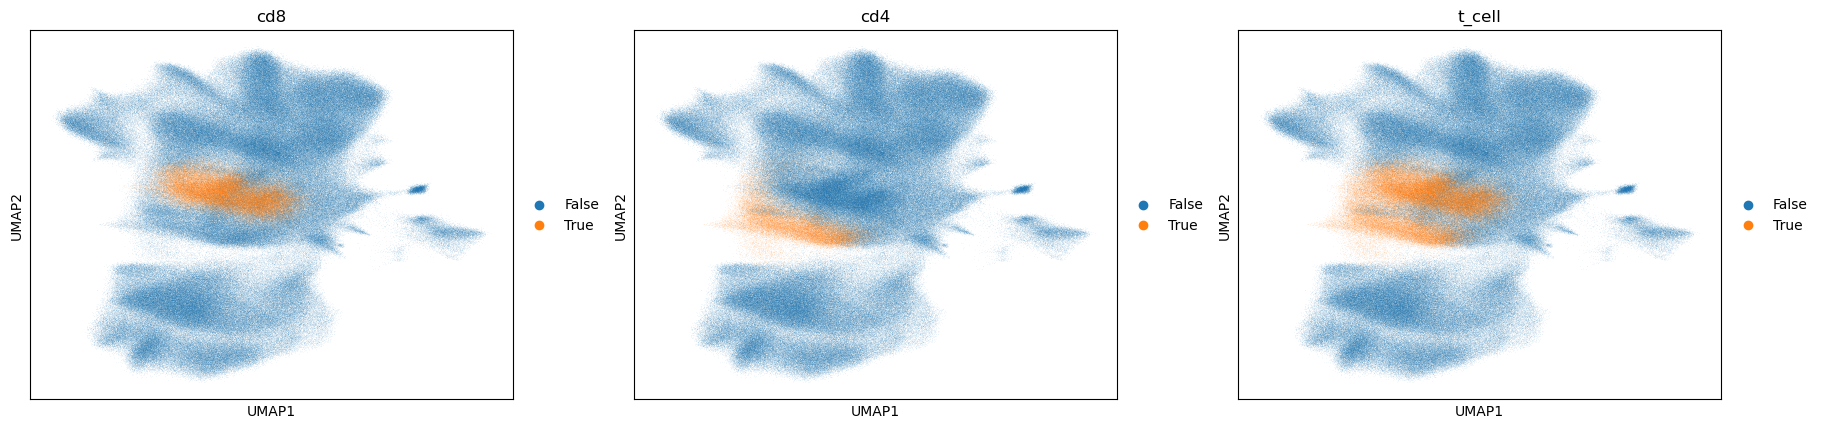

In [11]:
sc.pl.umap(adata, color=['cd8', 'cd4', 't_cell'])

In [12]:
print(f'Not t cell: {sum(~adata.obs['t_cell'])}')
print(f't cell: {sum(adata.obs['t_cell'])}')
print(f'cd8: {sum(adata.obs['cd8'])}')
print(f'cd4: {sum(adata.obs['cd4'])}')

Not t cell: 700334
t cell: 140053
cd8: 91676
cd4: 48377


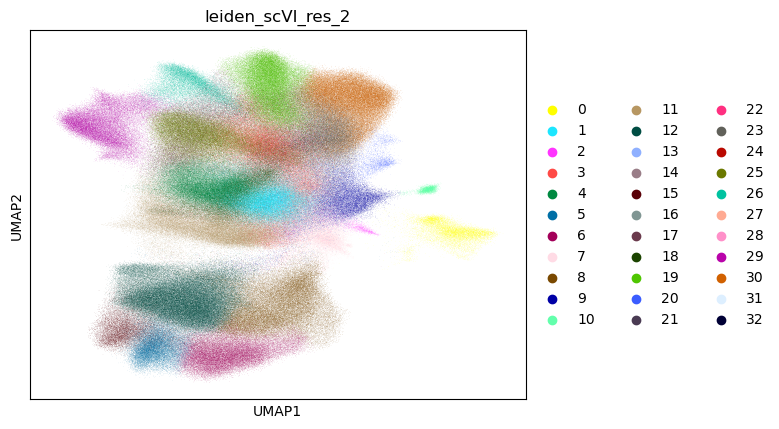

In [13]:
sc.pl.umap(adata, color=[res_label(2)])

In [14]:
def sub_res_label(res, clusters):
    """Order of clusters does not matter"""
    return f'sub_cluster_{"-".join(sorted(clusters))}_res_{res}'

def subcluster(adata, clusters, sub_res, clusters_res_label, de_genes_dict=None):
    print(f'Starting Sub Resolutions {sub_res}')
    new_col_name = sub_res_label(sub_res, clusters)

    # 2. Filter the adata to include only the targeted clusters
    subset_mask = adata.obs[clusters_res_label].isin(clusters)
    adata_sub = adata[subset_mask].copy()

    if new_col_name in adata.obs:
        print(f'{new_col_name} already in adata, skipping')
        # Re-load the existing labels into the subset for DE calculation
        adata_sub.obs[new_col_name] = adata.obs.loc[subset_mask, new_col_name].values
    else:
        # 3. Run the Leiden clustering on the subset
        sc.tl.leiden(adata_sub, resolution=sub_res, key_added=new_col_name, flavor='igraph')
        
        # 4. Initialize the new column in the original adata with "other"
        adata.obs[new_col_name] = "other"
        
        # 5. Map the subset's new cluster results back to the original adata
        adata.obs.loc[subset_mask, new_col_name] = adata_sub.obs[new_col_name].astype(str)
        adata.obs[new_col_name] = adata.obs[new_col_name].astype('category')
    
    # Dot plot base setup
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    
    # Compute top DE genes for each new subcluster
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby=new_col_name,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata_sub.uns['rank_genes_groups']
    sub_groups = result['names'].dtype.names
    
    # Add top 10 DE genes per subcluster to the dotplot
    for group in sub_groups:
        top_sub_genes = result['names'][group][:10]
        marker_genes_filt[f'Subcluster {group} Top DE'] = [g for g in top_sub_genes if g in adata.var_names]

    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=new_col_name,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers & Subcluster DE — {new_col_name}'
    )

    print(f"\nSub-cluster sizes for {new_col_name}:")
    print(adata.obs[new_col_name].value_counts())
    
    return adata

In [15]:
sub_resolutions = [1, 0.75, 0.5, 0.37, 0.25, 0.15, 0.1, 0.05]

In [16]:
for sub_res in sub_resolutions:
    subcluster(adata, cd4, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd4) for sub_res in sub_resolutions])

Starting Sub Resolutions 1
sub_cluster_5_res_1 already in adata, skipping


ValueError: Could not calculate statistics for groups other since they only contain one sample.

starting cd8
Starting Sub Resolutions 1


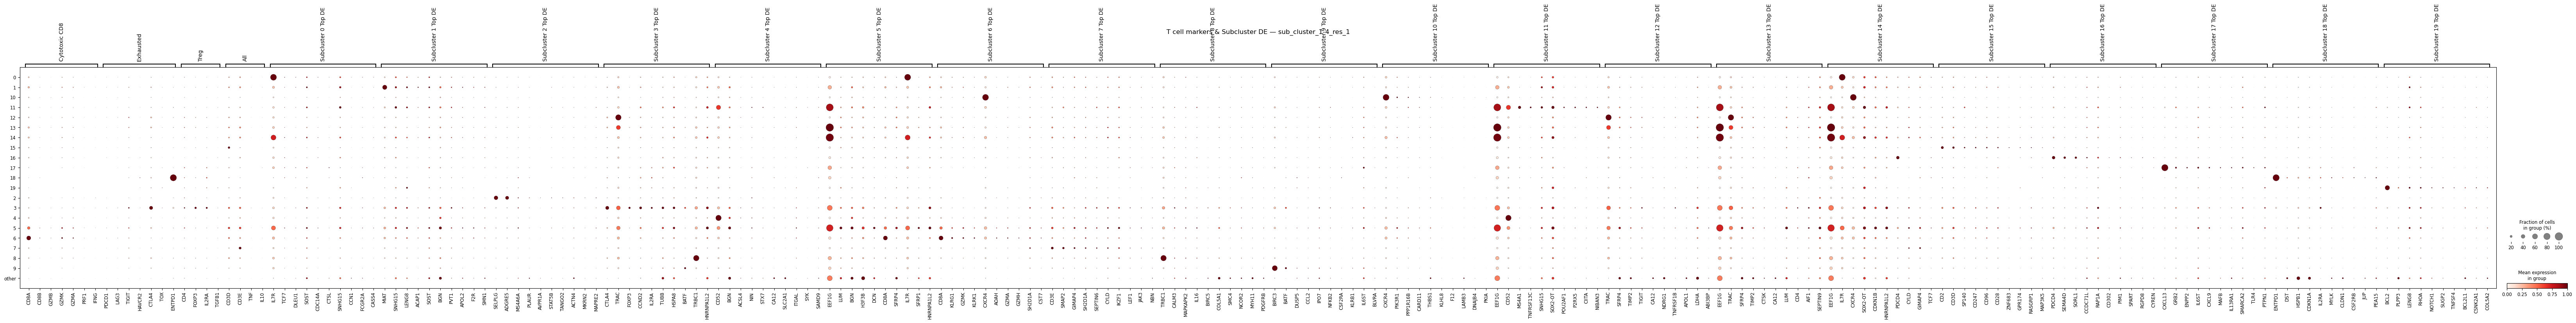


Sub-cluster sizes for sub_cluster_1-4_res_1:
sub_cluster_1-4_res_1
other    748711
5         14219
14        12397
3         11434
6          9692
0          7103
13         6935
11         6021
1          4821
12         4774
8          3395
7          3373
4          2321
10         1400
9          1265
15         1183
16          429
17          358
2           306
19          126
18          124
Name: count, dtype: int64
Starting Sub Resolutions 0.75


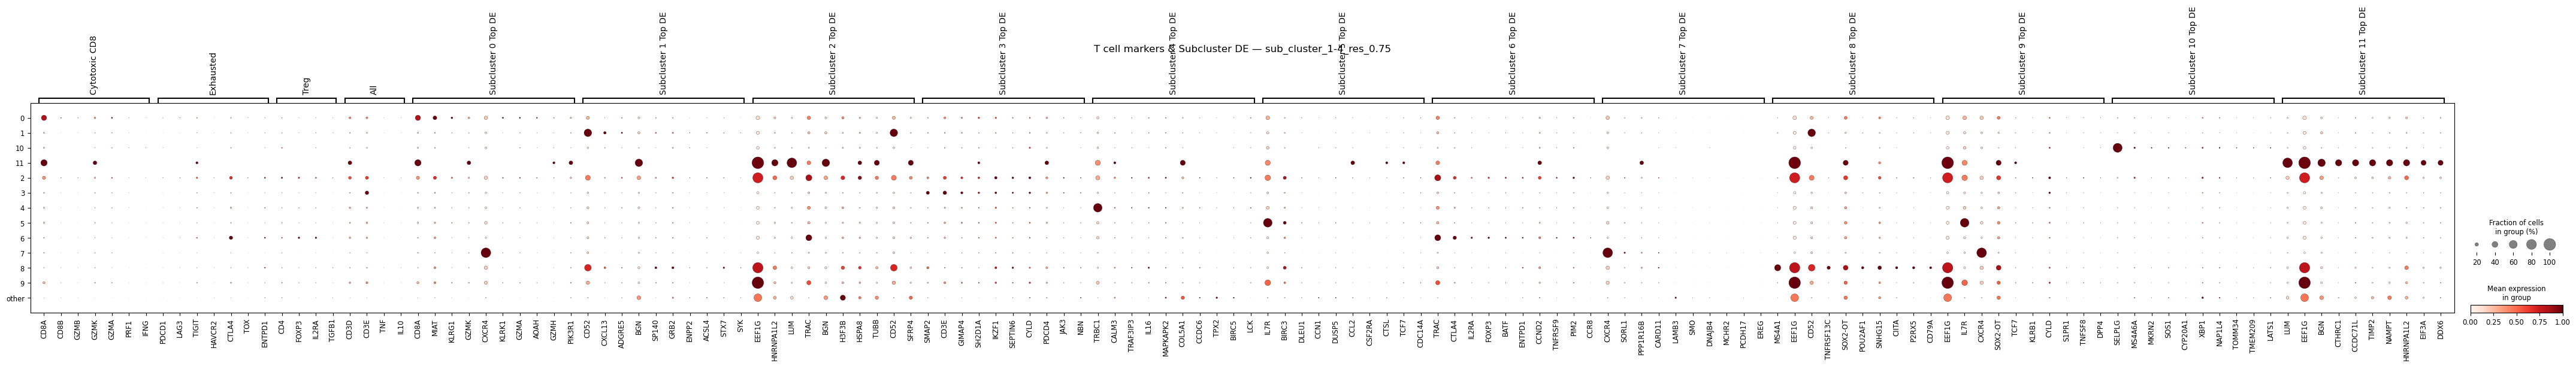


Sub-cluster sizes for sub_cluster_1-4_res_0.75:
sub_cluster_1-4_res_0.75
other    748711
9         24286
2         20347
0         15518
6         11800
5          8084
8          2895
3          2682
1          2448
4          2289
7          1156
10          162
11            9
Name: count, dtype: int64
Starting Sub Resolutions 0.5


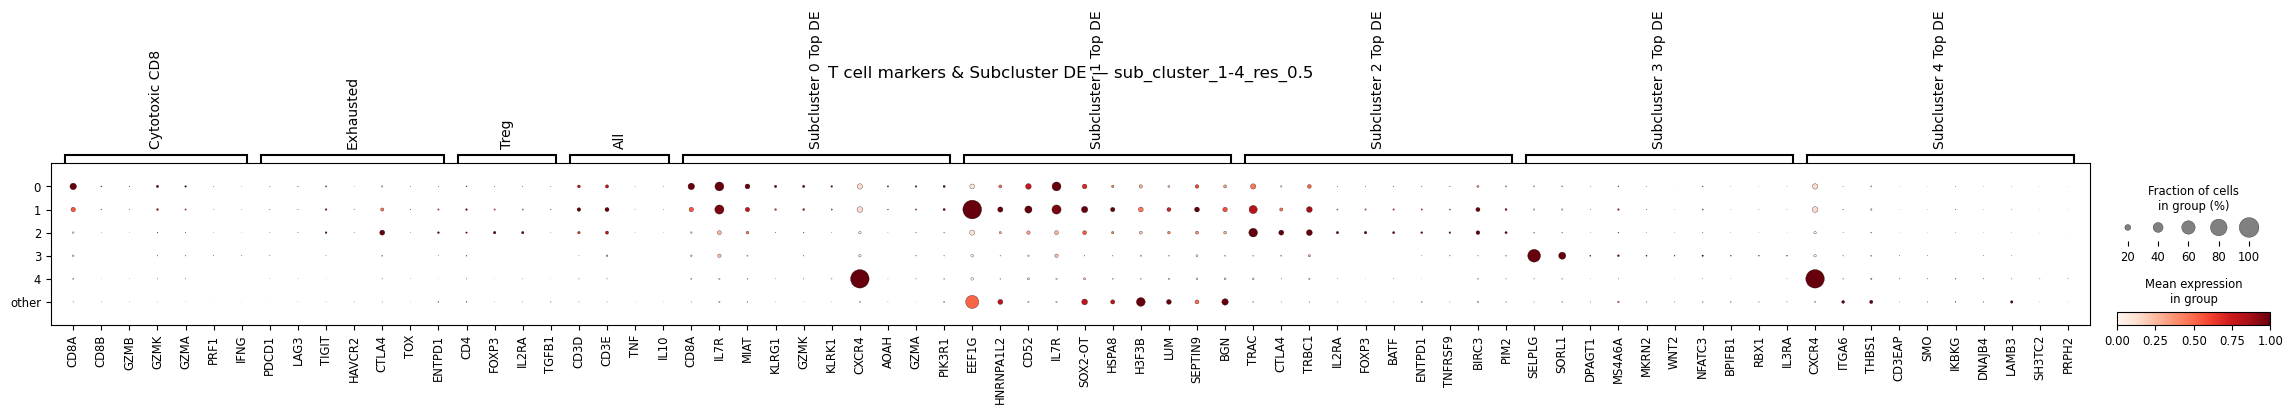


Sub-cluster sizes for sub_cluster_1-4_res_0.5:
sub_cluster_1-4_res_0.5
other    748711
1         47297
0         26504
2         16932
4           758
3           185
Name: count, dtype: int64
Starting Sub Resolutions 0.37


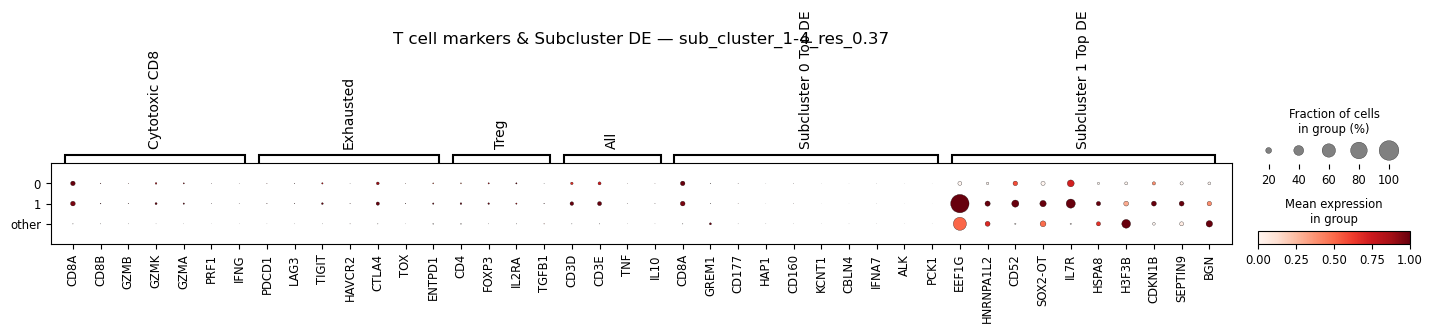


Sub-cluster sizes for sub_cluster_1-4_res_0.37:
sub_cluster_1-4_res_0.37
other    748711
1         50893
0         40783
Name: count, dtype: int64
Starting Sub Resolutions 0.25


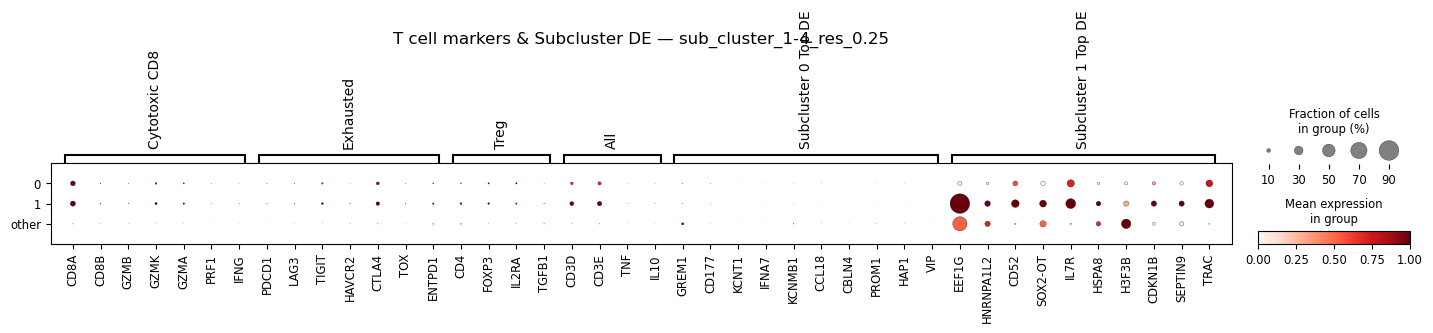


Sub-cluster sizes for sub_cluster_1-4_res_0.25:
sub_cluster_1-4_res_0.25
other    748711
1         52605
0         39071
Name: count, dtype: int64
Starting Sub Resolutions 0.15


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


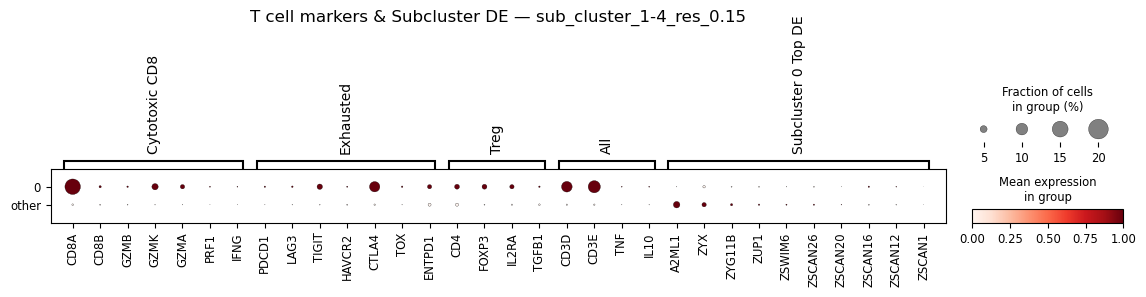


Sub-cluster sizes for sub_cluster_1-4_res_0.15:
sub_cluster_1-4_res_0.15
other    748711
0         91676
Name: count, dtype: int64
Starting Sub Resolutions 0.1


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


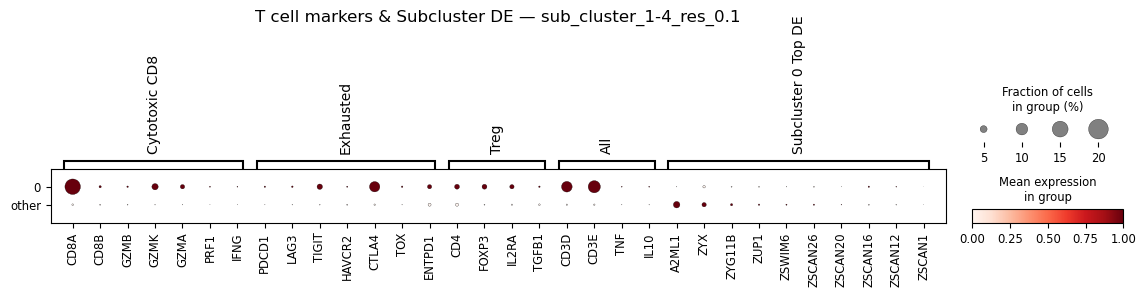


Sub-cluster sizes for sub_cluster_1-4_res_0.1:
sub_cluster_1-4_res_0.1
other    748711
0         91676
Name: count, dtype: int64
Starting Sub Resolutions 0.05


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


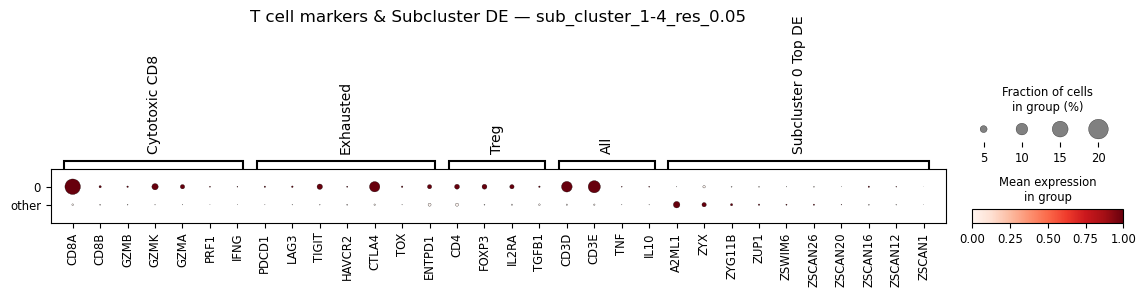


Sub-cluster sizes for sub_cluster_1-4_res_0.05:
sub_cluster_1-4_res_0.05
other    748711
0         91676
Name: count, dtype: int64


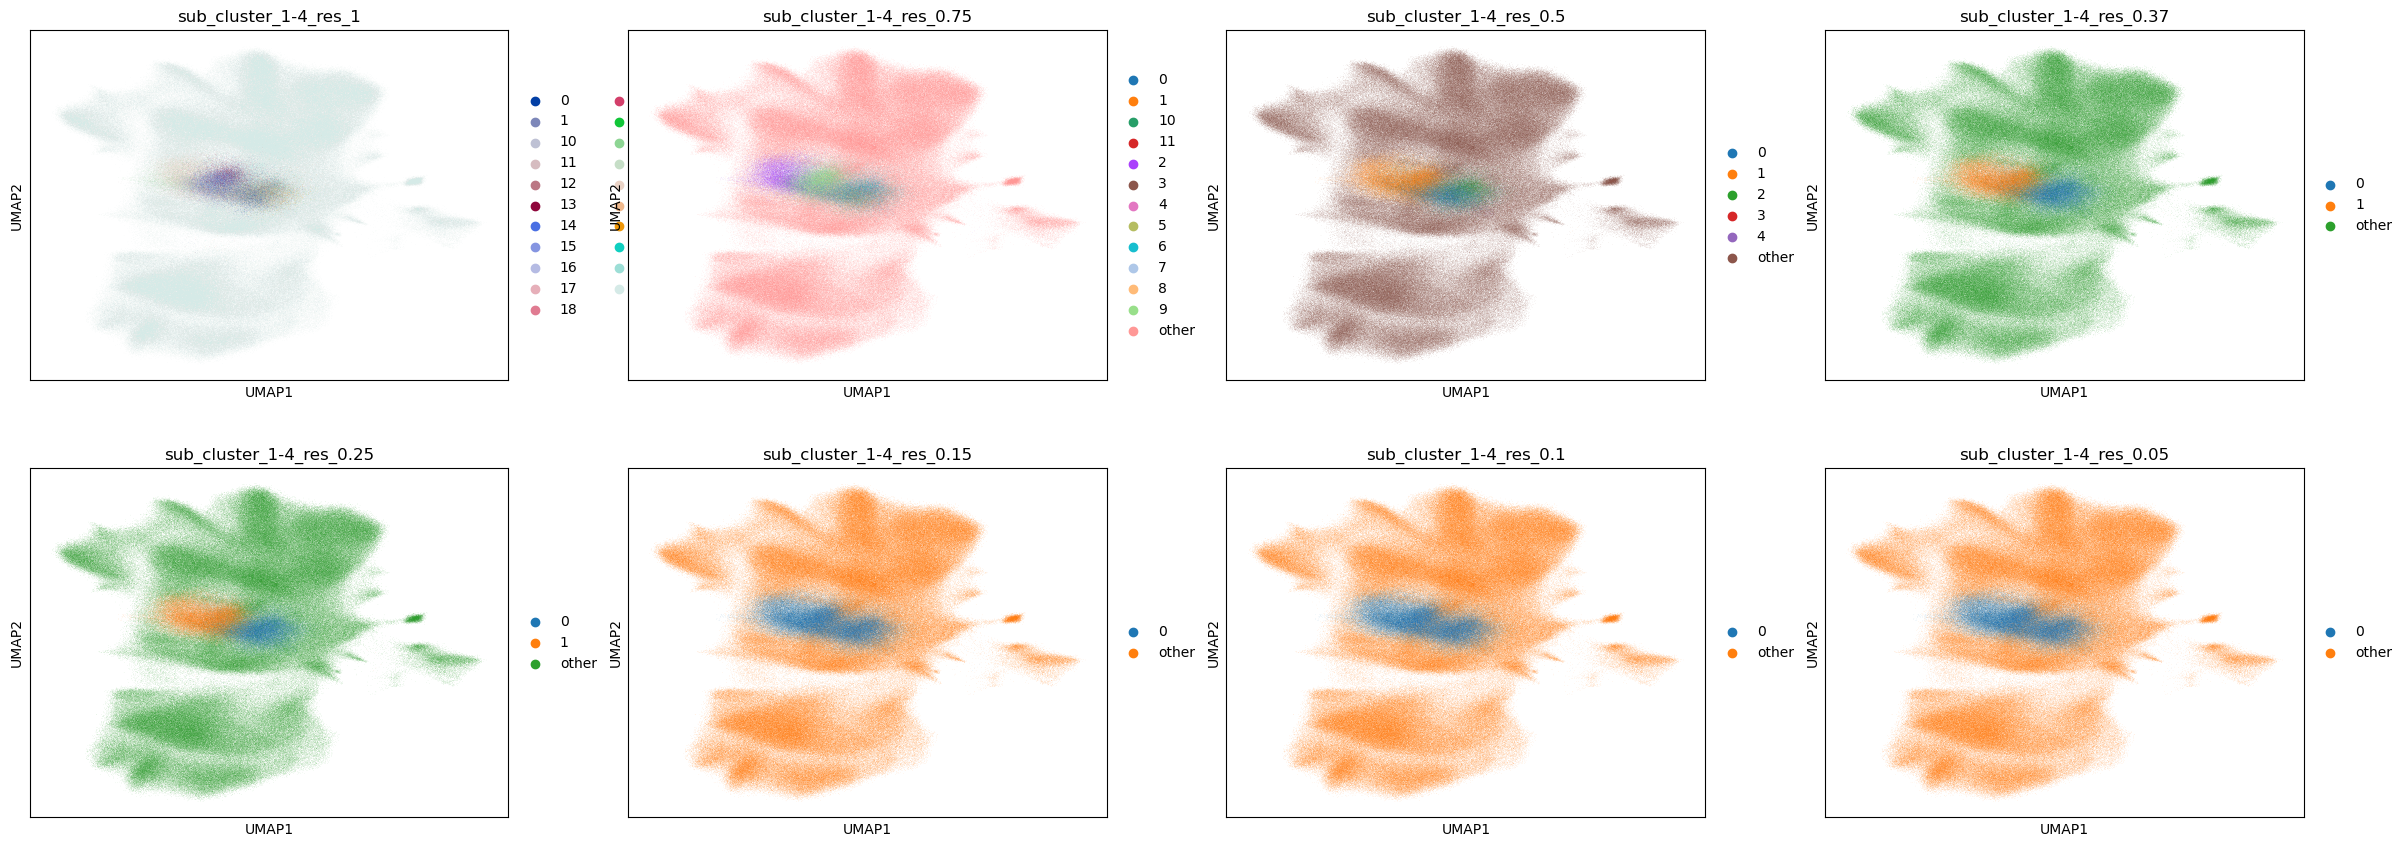

In [ ]:
print('starting cd8')
for sub_res in sub_resolutions:
    subcluster(adata, cd8, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd8) for sub_res in sub_resolutions])

In [ ]:
# ============================================================
# Time to assign  -  fine T-cell annotations from collaborator's notes.
# "We only want T cells": a cell is kept as a T cell ONLY if it lands in a
# subcluster she explicitly annotated. Everything else -- the contaminated CD4
# cluster(s) and any un-annotated CD8/CD4 subcluster -- is contamination/noise
# and set to 'other' at ALL tiers (Tier1 is removed for noise, not just Tier3).
#
# IMPORTANT: the sub-resolutions below MUST match those used in the subcluster
# loop above (sub_resolutions). We build the column via sub_res_label() and
# assert it exists so a resolution mismatch fails loudly instead of mislabeling.
# ============================================================

# --- CD8 subcluster annotations ---
cd8_sub_res = 0.5
cd8_labels = {'0': 'Memory CD8 T cell', '2': 'Exhausted/Activated CD8 T cell (CTLA4+)'}

# --- CD4 subcluster annotations ---  (None => CD4 is contamination)
cd4_sub_res = None
cd4_labels = {}

cd8_sub_col = sub_res_label(cd8_sub_res, cd8) if cd8_sub_res is not None else None
cd4_sub_col = sub_res_label(cd4_sub_res, cd4) if cd4_sub_res is not None else None
if cd8_sub_col is not None:
    assert cd8_sub_col in adata.obs, f"{cd8_sub_col} missing -- run the CD8 subcluster loop at res {cd8_sub_res}"
if cd4_sub_col is not None:
    assert cd4_sub_col in adata.obs, f"{cd4_sub_col} missing -- run the CD4 subcluster loop at res {cd4_sub_res}"

# Tier3: fine functional label, only for annotated subclusters
adata.obs['Tier3'] = 'other'
if cd8_sub_col is not None:
    for clust, label in cd8_labels.items():
        adata.obs.loc[adata.obs[cd8_sub_col] == clust, 'Tier3'] = label
if cd4_sub_col is not None:
    for clust, label in cd4_labels.items():
        adata.obs.loc[adata.obs[cd4_sub_col] == clust, 'Tier3'] = label
adata.obs['Tier3'] = adata.obs['Tier3'].astype('category')

# A cell is a real T cell iff it received a Tier3 label.
is_tcell = adata.obs['Tier3'] != 'other'

# Tier2: CD8- vs CD4-origin, only for confirmed T cells
adata.obs['Tier2'] = 'other'
if cd8_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd8_sub_col].isin(list(cd8_labels)), 'Tier2'] = 'CD8 T Cell'
if cd4_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd4_sub_col].isin(list(cd4_labels)), 'Tier2'] = 'CD4 T Cell'
adata.obs['Tier2'] = adata.obs['Tier2'].astype('category')

# Tier1: 'T Cell' ONLY where a fine label was assigned (noise/contamination dropped)
adata.obs['Tier1'] = np.where(is_tcell, 'T Cell', 'other')
adata.obs['Tier1'] = adata.obs['Tier1'].astype('category')

# Keep the exploratory boolean flags consistent with the cleaned annotation
adata.obs['t_cell'] = is_tcell
adata.obs['cd8'] = adata.obs['Tier2'] == 'CD8 T Cell'
adata.obs['cd4'] = adata.obs['Tier2'] == 'CD4 T Cell'

print("Tier1:\n", adata.obs['Tier1'].value_counts())
print("\nTier2:\n", adata.obs['Tier2'].value_counts())
print("\nTier3:\n", adata.obs['Tier3'].value_counts())


Tier1:
 Tier1
other     796951
T Cell     43436
Name: count, dtype: int64

Tier2:
 Tier2
other         796951
CD8 T Cell     43436
Name: count, dtype: int64

Tier3:
 Tier3
other                                      796951
Memory CD8 T cell                           26504
Exhausted/Activated CD8 T cell (CTLA4+)     16932
Name: count, dtype: int64


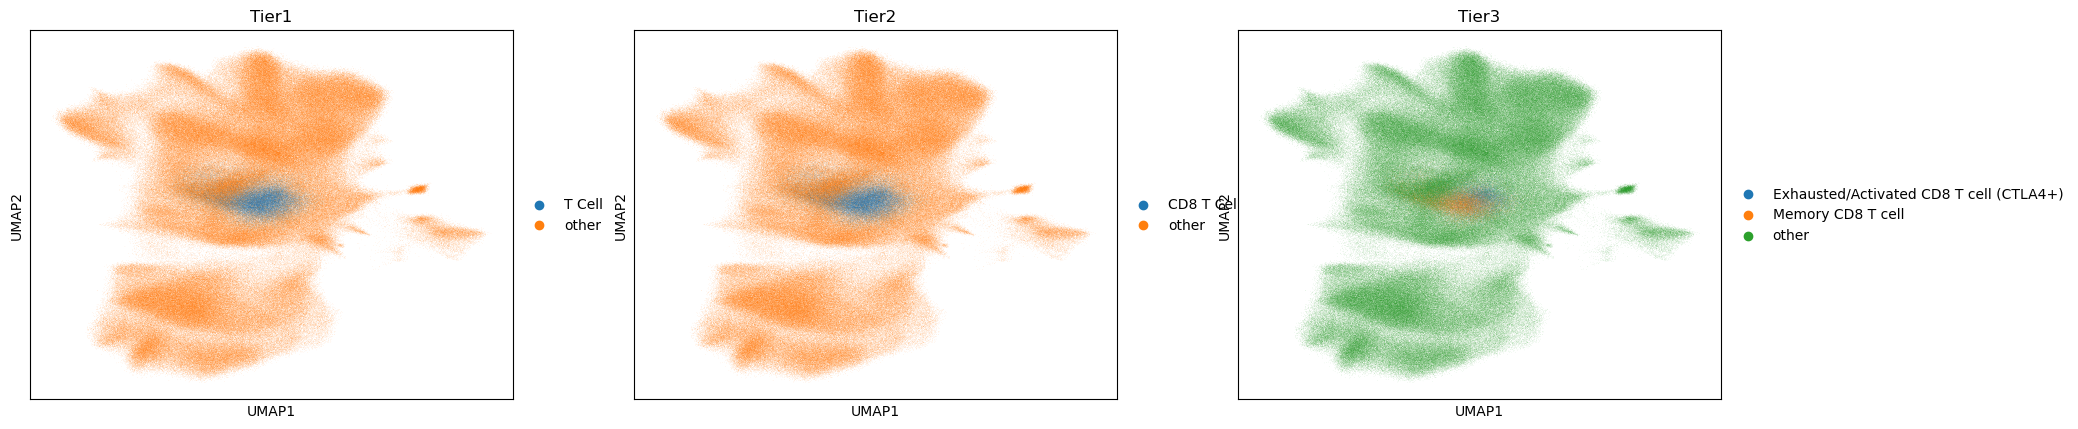

In [ ]:
sc.pl.umap(adata, color=['Tier1', 'Tier2', 'Tier3'])

In [ ]:
adata.write_h5ad(f'{DATA_DIR}/adata.h5ad')